# Skin Disease Detection - Training v3 (STABLE)
### ResNet50 + Balanced Weights + ReduceLROnPlateau

## Step 1: Imports & Config

In [19]:
import torch, torch.nn as nn, torch.optim as optim
import json, os, time, collections
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 1e-4
NUM_WORKERS = 4
VAL_SPLIT   = 0.2
MODEL_SAVE  = './model/resnet50_skin.pth'
LABELS_SAVE = './model/class_labels.json'
os.makedirs('./model', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3060
VRAM   : 12.9 GB


## Step 2: Load Dataset (already cached)

In [14]:
import kagglehub
path = kagglehub.dataset_download('ismailpromus/skin-diseases-image-dataset')
print('Path:', path)

best_dir, best_count = None, 0
for root, dirs, files in os.walk(path):
    if len(dirs) > best_count:
        best_count, best_dir = len(dirs), root

DATA_DIR = best_dir
print(f'Data dir : {DATA_DIR}')

Path: C:\Users\User\.cache\kagglehub\datasets\ismailpromus\skin-diseases-image-dataset\versions\1
Data dir : C:\Users\User\.cache\kagglehub\datasets\ismailpromus\skin-diseases-image-dataset\versions\1\IMG_CLASSES


## Step 3: Transforms & Data Loaders

In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

full_dataset = datasets.ImageFolder(root=DATA_DIR)
NUM_CLASSES  = len(full_dataset.classes)
CLASS_NAMES  = full_dataset.classes
class_counts = collections.Counter([s[1] for s in full_dataset.samples])

print(f'Total: {len(full_dataset)}  |  Classes: {NUM_CLASSES}')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {n:55s} {class_counts[i]:6d}')

with open(LABELS_SAVE,'w') as f: json.dump(CLASS_NAMES, f)
print(f'Labels saved -> {LABELS_SAVE}')

Total: 27153  |  Classes: 10
  1. Eczema 1677                                            1677
  10. Warts Molluscum and other Viral Infections - 2103     2103
  2. Melanoma 15.75k                                        3140
  3. Atopic Dermatitis - 1.25k                              1257
  4. Basal Cell Carcinoma (BCC) 3323                        3323
  5. Melanocytic Nevi (NV) - 7970                           7970
  6. Benign Keratosis-like Lesions (BKL) 2624               2079
  7. Psoriasis pictures Lichen Planus and related diseases - 2k   2055
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k    1847
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k   1702
Labels saved -> ../model/class_labels.json


In [4]:
val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))
train_ds.dataset.transform = train_tf
val_ds.dataset.transform   = val_tf

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f'Train: {train_size} ({len(train_loader)} batches)  Val: {val_size} ({len(val_loader)} batches)')

Train: 21723 (679 batches)  Val: 5430 (170 batches)


## Step 4: Class Weights + ResNet50 + Optimizer

In [5]:
# Balanced class weights (sklearn formula) — weights stay in safe range 0.3–6.0
total_s      = len(full_dataset)
loss_weights = torch.tensor(
    [total_s / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float).to(DEVICE)
print('Loss weights:')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {n:55s} {loss_weights[i].item():.3f}')

Loss weights:
  1. Eczema 1677                                          1.619
  10. Warts Molluscum and other Viral Infections - 2103   1.291
  2. Melanoma 15.75k                                      0.865
  3. Atopic Dermatitis - 1.25k                            2.160
  4. Basal Cell Carcinoma (BCC) 3323                      0.817
  5. Melanocytic Nevi (NV) - 7970                         0.341
  6. Benign Keratosis-like Lesions (BKL) 2624             1.306
  7. Psoriasis pictures Lichen Planus and related diseases - 2k 1.321
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k  1.470
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k 1.595


In [6]:
def build_resnet50(n):
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for p in m.parameters(): p.requires_grad = False
    for p in m.layer3.parameters(): p.requires_grad = True
    for p in m.layer4.parameters(): p.requires_grad = True
    m.fc = nn.Sequential(
        nn.Dropout(0.4), nn.Linear(m.fc.in_features, 512),
        nn.ReLU(),        nn.Dropout(0.3), nn.Linear(512, n)
    )
    return m

model     = build_resnet50(NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total_p:,}  ({100*trainable/total_p:.1f}%)')

criterion = nn.CrossEntropyLoss(weight=loss_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

# Safe scheduler: halves LR after 3 epochs of no val_acc improvement
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True)
print('Model + Optimizer + Scheduler ready.')

Trainable: 23,117,322 / 24,562,250  (94.1%)
Model + Optimizer + Scheduler ready.


e:\skin-disease-ai\.conda\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Step 5: Train

In [7]:
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, desc='Train' if train else 'Val', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum/total, correct/total

history   = {'tl':[], 'vl':[], 'ta':[], 'va':[]}
best_acc  = 0.0
pat_cnt   = 0
PAT       = 6

print(f'Training ResNet50 on {DEVICE} — up to {EPOCHS} epochs')
print('-'*70)

for ep in range(1, EPOCHS+1):
    t0 = time.time()
    tl, ta = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    vl, va = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, train=False)
    scheduler.step(va)
    history['tl'].append(tl); history['ta'].append(ta)
    history['vl'].append(vl); history['va'].append(va)
    print(f'Ep {ep:02d}/{EPOCHS}  Train {ta*100:.2f}% ({tl:.4f})  '
          f'Val {va*100:.2f}% ({vl:.4f})  {time.time()-t0:.0f}s')
    if va > best_acc:
        best_acc = va; pat_cnt = 0
        torch.save({'epoch':ep,'model_state':model.state_dict(),'val_acc':va,
                    'num_classes':NUM_CLASSES,'class_names':CLASS_NAMES}, MODEL_SAVE)
        print(f'  Saved best  val_acc={va*100:.2f}%')
    else:
        pat_cnt += 1
        if pat_cnt >= PAT:
            print(f'Early stop after {PAT} epochs without improvement.')
            break

print('-'*70)
print(f'Best Val Accuracy: {best_acc*100:.2f}%')

Training ResNet50 on cuda — up to 20 epochs
----------------------------------------------------------------------


Ep 01/20  Train 66.88% (1.0958)  Val 77.35% (0.7688)  185s
  Saved best  val_acc=77.35%


Ep 02/20  Train 82.64% (0.6227)  Val 80.70% (0.6857)  127s
  Saved best  val_acc=80.70%


Ep 03/20  Train 90.31% (0.3516)  Val 82.25% (0.7056)  132s
  Saved best  val_acc=82.25%


Ep 04/20  Train 94.19% (0.2092)  Val 83.85% (0.7307)  121s
  Saved best  val_acc=83.85%


...

Ep 16/20  Train 99.18% (0.0235)  Val 85.41% (1.2122)  121s
  Saved best  val_acc=85.41%


Ep 17/20  Train 99.06% (0.0266)  Val 85.08% (1.1732)  186s


Ep 18/20  Train 99.23% (0.0207)  Val 84.73% (1.2742)  123s


Ep 19/20  Train 99.22% (0.0220)  Val 84.33% (1.2420)  119s


Ep 20/20  Train 99.17% (0.0243)  Val 84.71% (1.2658)  113s
----------------------------------------------------------------------
Best Val Accuracy: 85.41%


## Step 6: Curves + Confusion Matrix + Per-Class Accuracy

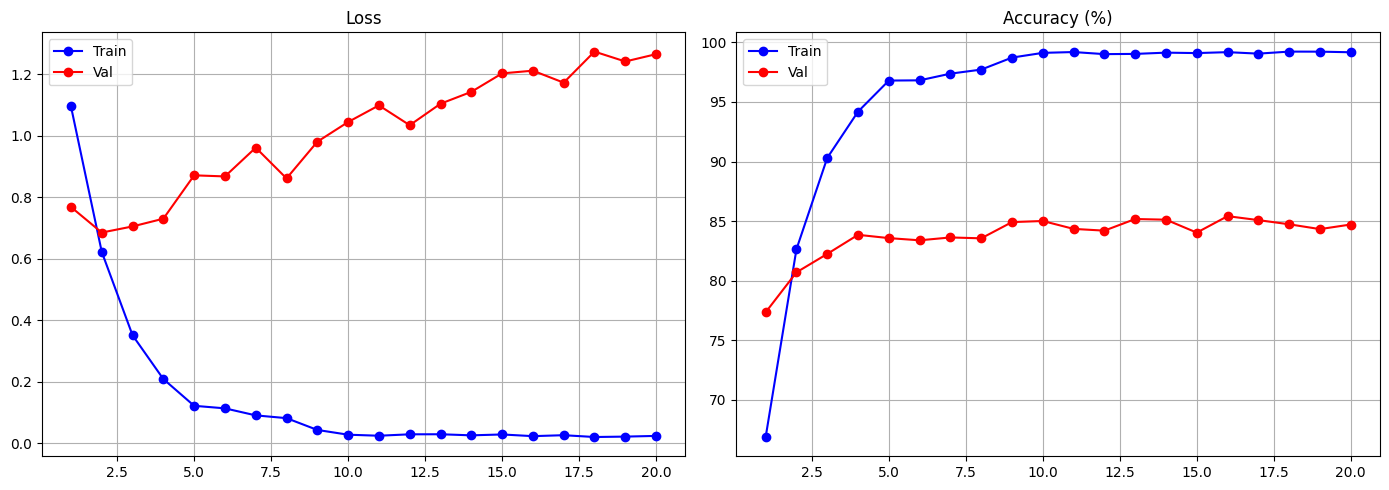

In [20]:
ep_r = range(1, len(history['tl'])+1)
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
a1.plot(ep_r,history['tl'],'b-o',label='Train'); a1.plot(ep_r,history['vl'],'r-o',label='Val')
a1.set_title('Loss'); a1.legend(); a1.grid(True)
a2.plot(ep_r,[x*100 for x in history['ta']],'b-o',label='Train')
a2.plot(ep_r,[x*100 for x in history['va']],'r-o',label='Val')
a2.set_title('Accuracy (%)'); a2.legend(); a2.grid(True)
plt.tight_layout(); plt.savefig('./model/curves_v3.png',dpi=100); plt.show()

In [ ]:
ckpt = torch.load(MODEL_SAVE, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
preds_all, labels_all = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(val_loader, desc='Eval'):
        preds_all.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
        labels_all.extend(lbls.numpy())

print(classification_report(labels_all, preds_all, target_names=CLASS_NAMES))

cm = confusion_matrix(labels_all, preds_all)
fig,ax=plt.subplots(figsize=(12,10))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax)
ax.set_title('Confusion Matrix v3'); ax.set_ylabel('True'); ax.set_xlabel('Pred')
plt.xticks(rotation=45,ha='right'); plt.tight_layout()
plt.savefig('./model/cm_v3.png',dpi=100); plt.show()

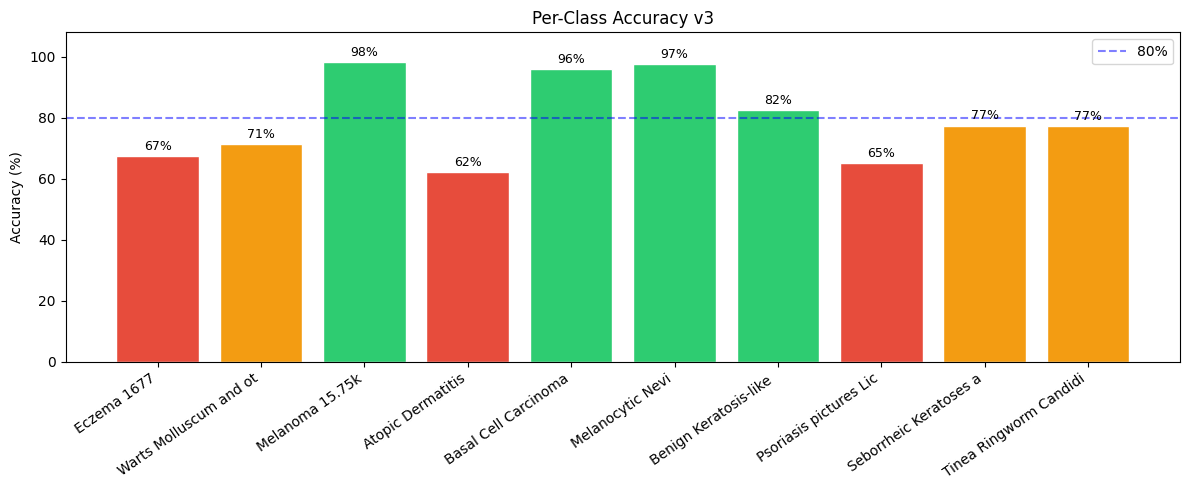

[WARN] 1. Eczema 1677                                          67.5%
[WARN] 10. Warts Molluscum and other Viral Infections - 2103   71.5%
[OK  ] 2. Melanoma 15.75k                                      98.2%
[BAD ] 3. Atopic Dermatitis - 1.25k                            62.2%
[OK  ] 4. Basal Cell Carcinoma (BCC) 3323                      95.9%
[OK  ] 5. Melanocytic Nevi (NV) - 7970                         97.5%
[OK  ] 6. Benign Keratosis-like Lesions (BKL) 2624             82.4%
[WARN] 7. Psoriasis pictures Lichen Planus and related diseases - 2k 65.2%
[WARN] 8. Seborrheic Keratoses and other Benign Tumors - 1.8k  77.4%
[WARN] 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k 77.3%


In [ ]:
pca   = cm.diagonal() / cm.sum(axis=1)
short = [n.split('. ',1)[-1].split(' -')[0].split(' (')[0][:22] for n in CLASS_NAMES]
cols  = ['#e74c3c' if a<0.70 else '#f39c12' if a<0.80 else '#2ecc71' for a in pca]
fig,ax=plt.subplots(figsize=(12,5))
bars=ax.bar(short,pca*100,color=cols,edgecolor='white')
ax.axhline(80,color='blue',linestyle='--',alpha=0.5,label='80%')
ax.set_ylim(0,108); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy v3')
plt.xticks(rotation=35,ha='right')
[ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{a*100:.0f}%',
         ha='center',va='bottom',fontsize=9) for b,a in zip(bars,pca)]
ax.legend(); plt.tight_layout()
plt.savefig('./model/pca_v3.png',dpi=100); plt.show()

for n,a in zip(CLASS_NAMES,pca):
    tag = 'OK  ' if a>=0.80 else 'WARN' if a>=0.65 else 'BAD '
    print(f'[{tag}] {n:55s} {a*100:.1f}%')

## Step 7: Auto-update app files

In [18]:
model_py = 'import torch\nimport torch.nn as nn\nfrom torchvision import models\nimport json, os\n\nBASE_DIR    = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))\nMODEL_PATH  = os.path.join(BASE_DIR, "model", "resnet50_skin.pth")\nLABELS_PATH = os.path.join(BASE_DIR, "model", "class_labels.json")\n\ndef build_model(num_classes):\n    m = models.resnet50(weights=None)\n    m.fc = nn.Sequential(\n        nn.Dropout(0.4), nn.Linear(m.fc.in_features, 512),\n        nn.ReLU(),        nn.Dropout(0.3), nn.Linear(512, num_classes))\n    return m\n\ndef load_model():\n    with open(LABELS_PATH) as f: class_names = json.load(f)\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    ckpt = torch.load(MODEL_PATH, map_location=device)\n    m    = build_model(ckpt.get("num_classes", len(class_names)))\n    m.load_state_dict(ckpt["model_state"])\n    m.to(device).eval()\n    print(f"[Model] ResNet50 loaded  val_acc={ckpt.get(\'val_acc\',0):.4f}")\n    return m, class_names, device\n\ndef predict(tensor, model, class_names, device):\n    with torch.no_grad():\n        probs = torch.softmax(model(tensor.to(device)), dim=1)[0]\n        top5  = torch.topk(probs, k=min(5, len(class_names)))\n    return (class_names[top5.indices[0].item()],\n            top5.values[0].item(),\n            [{"disease": class_names[top5.indices[i].item()],\n              "confidence": round(top5.values[i].item(), 4)} for i in range(top5.indices.shape[0])])\n'

preprocess_py = 'import torch\nfrom torchvision import transforms\nfrom PIL import Image\nimport io\n\nIMG_SIZE = 224\ntransform = transforms.Compose([\n    transforms.Resize((IMG_SIZE, IMG_SIZE)),\n    transforms.ToTensor(),\n    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])\n])\n\ndef preprocess_image(image_bytes: bytes):\n    return transform(Image.open(io.BytesIO(image_bytes)).convert("RGB")).unsqueeze(0)\n'

with open('./app/model.py', 'w') as f: f.write(model_py)
with open('./app/preprocess.py', 'w') as f: f.write(preprocess_py)
print('app/model.py and app/preprocess.py updated.')

print('\n--- Files in ./model/ ---')
for fn in os.listdir('./model'):
    sz = os.path.getsize(f'./model/{fn}') / 1e6
    print(f'  {fn:40s} {sz:.1f} MB')

app/model.py and app/preprocess.py updated.

--- Files in ./model/ ---
  class_labels.json                        0.0 MB
  confusion_matrix.png                     0.1 MB
  sample_images.png                        1.1 MB
  training_curves.png                      0.1 MB
